# Deep quantum mechanics for quantum photonics: the harmonic oscillator is a photon

Griffiths solves the quantum harmonic oscillator twice: the brute-force Hermite-polynomial way, and the
**algebraic (ladder-operator) way** with $a$ and $a^\dagger$. The algebraic solution is not just elegant --
it *is* quantum photonics. Each mode of the quantized electromagnetic field is a harmonic oscillator, and
its quantized energy levels are **photons**:

$$H=\hbar\omega\!\left(a^\dagger a+\tfrac12\right),\qquad E_n=\left(n+\tfrac12\right)\hbar\omega,\qquad
a^\dagger|n\rangle=\sqrt{n+1}\,|n+1\rangle .$$

$a^\dagger$ **creates a photon**, $a$ **annihilates** one, $|n\rangle$ is the $n$-photon **Fock state**, and
the ground state $|0\rangle$ -- the vacuum -- still carries $\tfrac12\hbar\omega$ of **zero-point energy**
with irreducible fluctuations. **Laser light** is a *coherent state* $|\alpha\rangle$, an eigenstate of
$a$, whose photon number is **Poisson-distributed** -- and that Poisson spread is exactly the **shot
noise** that sets the floor of the dispersion phase-retrieval instrument in this repository.

This notebook builds that bridge and verifies every step:
- ladder operators in the number basis, $[a,a^\dagger]=1$, $H$, $E_n$ (NumPy);
- the Griffiths algebraic derivation from $[x,p]=i\hbar$ (SymPy);
- the Hermite-polynomial stationary states solving the TISE (SymPy, Griffiths Ch. 2);
- **photons and Fock states**; **coherent states = laser light** with Poisson/shot-noise statistics;
- **quadratures** and the vacuum uncertainty floor; and the shot-noise SNR a computer engineer budgets.

Self-contained: NumPy, SymPy, Pandas, Matplotlib. Units $\hbar=m=\omega=1$ for the numerics.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## Ladder operators in the number basis

Represent the operators as matrices on a truncated Fock space $\{|0\rangle,\dots,|N-1\rangle\}$. The
lowering operator has $\langle n-1|a|n\rangle=\sqrt n$; the raising operator is its adjoint. Then the
number operator $N=a^\dagger a=\mathrm{diag}(0,1,2,\dots)$, and $H=a^\dagger a+\tfrac12$ has eigenvalues
$n+\tfrac12$. The commutator $[a,a^\dagger]=1$ holds exactly except in the last row/column, where the
truncation bites -- a numerical fact the computer engineer must respect.

In [2]:
Ndim = 40
a = np.diag(np.sqrt(np.arange(1, Ndim)), 1)          # <n-1| a |n> = sqrt(n)  (superdiagonal)
adag = a.conj().T                                    # raising operator
comm = a @ adag - adag @ a                           # [a, a^dagger]
assert np.allclose(np.diag(comm)[:-1], 1.0)          # = 1 except the truncated last entry
Nop = adag @ a
assert np.allclose(np.diag(Nop), np.arange(Ndim))    # number operator = diag(0,1,2,...)
H = Nop + 0.5*np.eye(Ndim)
E = np.linalg.eigvalsh(H)
assert np.allclose(E, np.arange(Ndim) + 0.5)         # E_n = (n + 1/2) hbar omega
print("[a, a^dagger] = 1 (first entries):", np.round(np.diag(comm)[:5], 3))
print("E_0..E_4 =", np.round(E[:5], 3), " (n + 1/2)   zero-point energy E_0 =", round(E[0], 3))

[a, a^dagger] = 1 (first entries): [1. 1. 1. 1. 1.]
E_0..E_4 = [0.5 1.5 2.5 3.5 4.5]  (n + 1/2)   zero-point energy E_0 = 0.5


## The Griffiths algebraic derivation (from the canonical commutator)

Define $a=\dfrac{m\omega x+ip}{\sqrt{2\hbar m\omega}}$, $a^\dagger=\dfrac{m\omega x-ip}{\sqrt{2\hbar
m\omega}}$. Using only $[x,p]=i\hbar$, SymPy verifies the two facts the whole theory rests on:
$[a,a^\dagger]=1$, and $\hbar\omega\!\left(a^\dagger a+\tfrac12\right)=\dfrac{p^2}{2m}+\tfrac12 m\omega^2
x^2=H$. The **ladder** then follows from $[N,a^\dagger]=a^\dagger$: acting with $a^\dagger$ raises the
number eigenvalue by one -- it creates a quantum (a photon).

In [3]:
x, p = sp.symbols('x p', commutative=False)          # non-commuting operators
hbar, mm, w = sp.symbols('hbar m omega', positive=True)
sub = {x*p: p*x + sp.I*hbar}                          # the canonical commutator [x,p]=i hbar
norm = sp.sqrt(2*hbar*mm*w)
a_op   = (mm*w*x + sp.I*p)/norm
adag_op = (mm*w*x - sp.I*p)/norm

def normal_order(expr):                               # push every x*p -> p*x + i hbar (iterate to fixpoint)
    prev, cur = None, sp.expand(expr)
    while cur != prev:                                # repeat so embedded x*p (e.g. in x*p*x) resolves too
        prev, cur = cur, sp.expand(cur.subs(sub))
    return cur

comm_symbolic = normal_order(a_op*adag_op - adag_op*a_op)
assert sp.simplify(comm_symbolic - 1) == 0            # [a, a^dagger] = 1
print("[a, a^dagger] =", sp.simplify(comm_symbolic))

H_ladder = normal_order(hbar*w*(adag_op*a_op + sp.Rational(1,2)))
H_phys   = p**2/(2*mm) + sp.Rational(1,2)*mm*w**2*x**2
assert sp.simplify(H_ladder - H_phys) == 0           # hbar w (a^dag a + 1/2) = p^2/2m + 1/2 m w^2 x^2
print("hbar*omega*(a^dag a + 1/2) =", sp.simplify(H_ladder), " = H")

N_op = adag_op*a_op
raise_comm = normal_order(N_op*adag_op - adag_op*N_op)
assert sp.simplify(raise_comm - adag_op) == 0        # [N, a^dagger] = a^dagger  (the ladder)
print("[N, a^dagger] = a^dagger  ->  a^dagger raises n by 1 (creates a photon)")

[a, a^dagger] = 1
hbar*omega*(a^dag a + 1/2) = (m*omega**2*x**2 + p**2/m)/2  = H
[N, a^dagger] = a^dagger  ->  a^dagger raises n by 1 (creates a photon)


## Stationary states: Hermite polynomials solving the TISE (Griffiths Ch. 2)

The position-space eigenstates are $\psi_n(\xi)=\dfrac{1}{\sqrt{2^n n!\sqrt\pi}}\,H_n(\xi)\,e^{-\xi^2/2}$
with $\xi=\sqrt{m\omega/\hbar}\,x$ ($H_n$ the physicists' Hermite polynomial). SymPy confirms they solve
$-\tfrac12\psi''+\tfrac12\xi^2\psi=(n+\tfrac12)\psi$ and are orthonormal. The ground state $\psi_0$ is a
Gaussian -- the **vacuum** wavefunction.

In [4]:
xi = sp.symbols('xi', real=True)
def psi(n):
    return sp.hermite(n, xi)*sp.exp(-xi**2/2) / sp.sqrt(2**n*sp.factorial(n)*sp.sqrt(sp.pi))
for n in range(4):
    TISE = sp.simplify(-psi(n).diff(xi, 2)/2 + xi**2*psi(n)/2 - (n + sp.Rational(1,2))*psi(n))
    assert TISE == 0                                  # each psi_n solves the TISE with E_n=n+1/2
assert sp.integrate(psi(0)**2, (xi, -sp.oo, sp.oo)) == 1                     # normalized
assert sp.simplify(sp.integrate(psi(0)*psi(2), (xi, -sp.oo, sp.oo))) == 0   # orthogonal
print("psi_0..psi_3 solve the TISE with E_n = n + 1/2; orthonormal.  psi_0 =", psi(0))

psi_0..psi_3 solve the TISE with E_n = n + 1/2; orthonormal.  psi_0 = exp(-xi**2/2)/pi**(1/4)


## Photons, Fock states, and the vacuum

The quantum-photonics dictionary: a single field mode of frequency $\omega$ is this oscillator; its
excitation number $n$ is the **number of photons**; $|n\rangle$ is the **Fock state** of energy
$n\hbar\omega$ above the vacuum. $a^\dagger$ adds a photon ($\sqrt{n+1}$), $a$ removes one ($\sqrt n$),
and $a|0\rangle=0$: you cannot take a photon from the vacuum. Yet the vacuum is not "nothing" -- it holds
$\tfrac12\hbar\omega$ of zero-point energy, the source of vacuum fluctuations (spontaneous emission, the
Casimir force, the shot-noise floor).

In [5]:
fock = lambda n: np.eye(Ndim)[n]
# a^dagger creates: a^dag |n> = sqrt(n+1) |n+1>;  a annihilates: a|n> = sqrt(n)|n-1>;  a|0> = 0
assert np.allclose(adag @ fock(3), np.sqrt(4)*fock(4))
assert np.allclose(a @ fock(3), np.sqrt(3)*fock(2))
assert np.allclose(a @ fock(0), 0)                   # vacuum cannot be lowered
print("a^dag|3> = sqrt(4)|4>,  a|3> = sqrt(3)|2>,  a|0> = 0")
print("photon number in |n> = <n|N|n>:", [int(round(fock(n) @ Nop @ fock(n))) for n in range(5)])

a^dag|3> = sqrt(4)|4>,  a|3> = sqrt(3)|2>,  a|0> = 0
photon number in |n> = <n|N|n>: [0, 1, 2, 3, 4]


## Coherent states are laser light: Poisson photons and shot noise

A **coherent state** $|\alpha\rangle=e^{-|\alpha|^2/2}\sum_n \dfrac{\alpha^n}{\sqrt{n!}}|n\rangle$ is the
eigenstate of the annihilation operator, $a|\alpha\rangle=\alpha|\alpha\rangle$ -- the quantum state of an
ideal **laser**. Its photon-number distribution is **Poisson**,
$P(n)=e^{-|\alpha|^2}\dfrac{|\alpha|^{2n}}{n!}$, with mean $\langle n\rangle=|\alpha|^2$ and variance
$\mathrm{Var}(n)=|\alpha|^2$. Hence the fractional fluctuation is
$$\frac{\Delta n}{\langle n\rangle}=\frac{1}{\sqrt{\langle n\rangle}},$$
the **shot noise** -- the $\sqrt N$ counting noise that limits every photon measurement, including the
dispersed-intensity measurements this repository does phase retrieval on.

In [6]:
import math
def coherent(alpha, N=Ndim):
    n = np.arange(N)
    c = np.exp(-abs(alpha)**2/2) * alpha**n / np.sqrt(np.array([math.factorial(k) for k in n], float))
    return c/np.linalg.norm(c)                        # renormalize (Fock truncation)
alpha = 2.0
psi_a = coherent(alpha)
assert np.linalg.norm(a @ psi_a - alpha*psi_a) < 1e-6      # eigenstate of annihilation: a|alpha>=alpha|alpha>
Pn = np.abs(psi_a)**2
n = np.arange(Ndim)
poisson = np.exp(-abs(alpha)**2)*abs(alpha)**(2*n)/np.array([math.factorial(k) for k in n], float)
assert np.allclose(Pn, poisson, atol=1e-6)                 # photon number is Poisson
mean = float(np.sum(n*Pn)); var = float(np.sum((n-mean)**2*Pn))
assert abs(mean - alpha**2) < 1e-3 and abs(var - alpha**2) < 1e-3   # <n>=Var=|alpha|^2
print(f"|alpha={alpha}>:  <n> = {mean:.3f},  Var(n) = {var:.3f}  (equal -> Poisson)")
print(f"shot noise  Delta n/<n> = {np.sqrt(var)/mean:.3f}  vs  1/sqrt(<n>) = {1/np.sqrt(mean):.3f}")

|alpha=2.0>:  <n> = 4.000,  Var(n) = 4.000  (equal -> Poisson)
shot noise  Delta n/<n> = 0.500  vs  1/sqrt(<n>) = 0.500


## Quadratures and the vacuum uncertainty floor

Write the field in **quadratures** $X=\tfrac12(a+a^\dagger)$, $P=\tfrac1{2i}(a-a^\dagger)$ (the in-phase
and out-of-phase amplitudes a homodyne detector measures). The vacuum saturates the uncertainty relation,
$\Delta X\,\Delta P=\tfrac14$, split equally between the quadratures -- and a coherent state is just a
**displaced vacuum**, carrying that same minimum-uncertainty disk out to amplitude $\alpha$. Pushing the
noise of one quadrature below $\tfrac12$ (at the other's expense) is **squeezed light**, the resource
behind sub-shot-noise interferometry (LIGO, quantum sensing).

In [7]:
X = (a + adag)/2
Pq = (a - adag)/(2j)
def uncertainty(op, psi):
    m1 = np.real(psi.conj() @ op @ psi)
    m2 = np.real(psi.conj() @ (op @ op) @ psi)
    return np.sqrt(max(m2 - m1**2, 0.0))
vac = fock(0)
dX, dP = uncertainty(X, vac), uncertainty(Pq, vac)
print(f"vacuum:    dX = {dX:.4f}, dP = {dP:.4f}, product = {dX*dP:.4f}  (= 1/4, minimum uncertainty)")
assert abs(dX*dP - 0.25) < 1e-6
dXc, dPc = uncertainty(X, psi_a), uncertainty(Pq, psi_a)
print(f"coherent:  dX = {dXc:.4f}, dP = {dPc:.4f}, product = {dXc*dPc:.4f}  (displaced vacuum, still 1/4)")
assert abs(dXc*dPc - 0.25) < 1e-3
print(f"<X> of |alpha={alpha}> = {np.real(psi_a.conj() @ X @ psi_a):.3f}  (= Re(alpha) = {alpha}) -> displacement")

vacuum:    dX = 0.5000, dP = 0.5000, product = 0.2500  (= 1/4, minimum uncertainty)
coherent:  dX = 0.5000, dP = 0.5000, product = 0.2500  (displaced vacuum, still 1/4)
<X> of |alpha=2.0> = 2.000  (= Re(alpha) = 2.0) -> displacement


## Engineering payoff: the shot-noise SNR a computer engineer budgets

Because a laser's photon count is Poisson, detecting $\langle n\rangle$ photons gives signal-to-noise
$\mathrm{SNR}=\langle n\rangle/\sqrt{\langle n\rangle}=\sqrt{\langle n\rangle}$. This single formula sets
the exposure/power budget of the dispersion instrument: to resolve intensity to $1\%$ you need
$\langle n\rangle\ge10^4$ photons per sample. The computer engineer works in the **truncated Fock basis**
(finite matrices), so they also track the truncation error that $[a,a^\dagger]=1$ exposed at the top of
the ladder. Deep QM sets the noise floor; the engineer sizes the system to it.

In [8]:
rows = []
for nbar in [1e2, 1e4, 5.4e2, 1e6]:
    rows.append({"mean photons <n>": f"{nbar:.0f}", "shot noise sqrt<n>": f"{np.sqrt(nbar):.1f}",
                 "SNR = sqrt<n>": f"{np.sqrt(nbar):.1f}", "rel. precision 1/sqrt<n>": f"{1/np.sqrt(nbar):.4f}"})
print(pd.DataFrame(rows).to_string(index=False))
print("\n540 photons -> ~4.3% precision (the per-classification budget from the throughput notebook)")
# Fock truncation: the commutator defect at the top level scales the modeling error
print(f"truncation defect [a,a^dag]_last = {np.diag(comm)[-1]:.1f}  (why Ndim must exceed the photon numbers used)")

mean photons <n> shot noise sqrt<n> SNR = sqrt<n> rel. precision 1/sqrt<n>
             100               10.0          10.0                   0.1000
           10000              100.0         100.0                   0.0100
             540               23.2          23.2                   0.0430
         1000000             1000.0        1000.0                   0.0010

540 photons -> ~4.3% precision (the per-classification budget from the throughput notebook)
truncation defect [a,a^dag]_last = -39.0  (why Ndim must exceed the photon numbers used)


## Plots

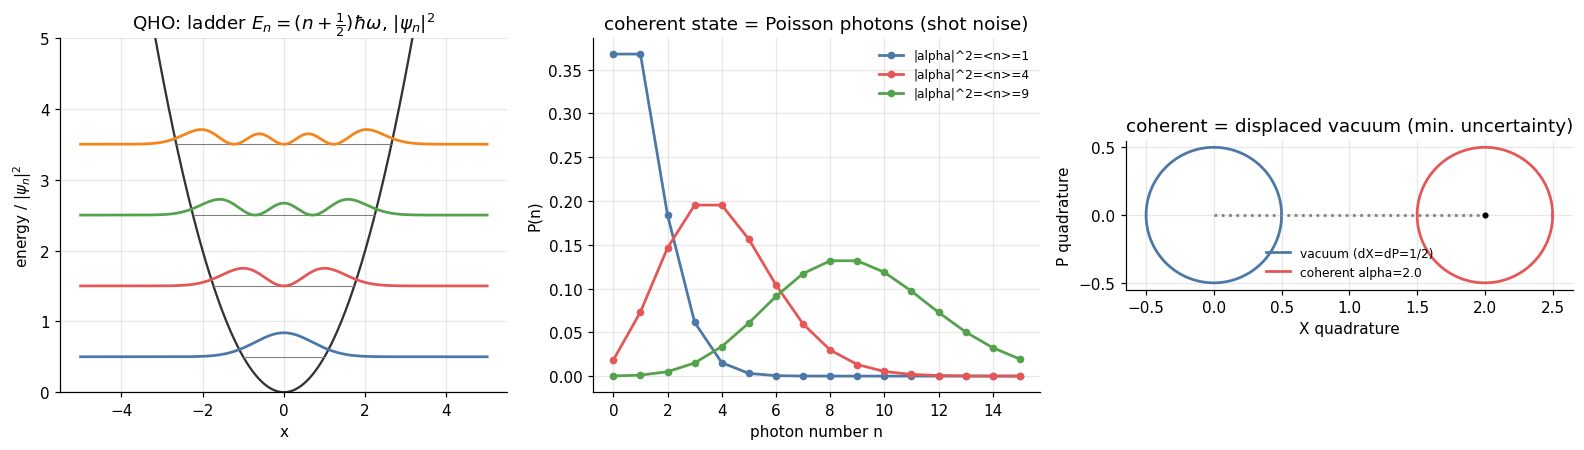

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) oscillator potential, energy ladder, and |psi_n(x)|^2 (the vacuum + first excitations)
import numpy as _np
xg = _np.linspace(-5, 5, 400)
ax[0].plot(xg, 0.5*xg**2, color="#333", lw=1.5)
from numpy.polynomial.hermite import hermval
for nlev in range(4):
    coef = _np.zeros(nlev+1); coef[nlev] = 1
    Hn = hermval(xg, coef)
    psin = Hn*_np.exp(-xg**2/2)/_np.sqrt(2.0**nlev*math.factorial(nlev)*_np.sqrt(_np.pi))
    ax[0].hlines(nlev+0.5, -_np.sqrt(2*(nlev+0.5)), _np.sqrt(2*(nlev+0.5)), color="gray", lw=0.7)
    ax[0].plot(xg, 0.6*psin**2 + nlev + 0.5)
ax[0].set_ylim(0, 5); ax[0].set_xlabel("x"); ax[0].set_ylabel("energy / $|\\psi_n|^2$")
ax[0].set_title(r"QHO: ladder $E_n=(n+\frac{1}{2})\hbar\omega$, $|\psi_n|^2$")
# (2) Poisson photon statistics of coherent (laser) states
for al, col in [(1.0, "#4C78A8"), (2.0, "#E45756"), (3.0, "#54A24B")]:
    nn = _np.arange(0, 16)
    pn = _np.exp(-al**2)*al**(2*nn)/_np.array([math.factorial(int(k)) for k in nn], float)
    ax[1].plot(nn, pn, "o-", color=col, ms=4, label=f"|alpha|^2=<n>={al**2:.0f}")
ax[1].set_xlabel("photon number n"); ax[1].set_ylabel("P(n)")
ax[1].set_title("coherent state = Poisson photons (shot noise)"); ax[1].legend(fontsize=8)
# (3) phase-space uncertainty disks: vacuum at origin, coherent displaced to alpha
th = _np.linspace(0, 2*_np.pi, 100)
ax[2].plot(0.5*_np.cos(th), 0.5*_np.sin(th), color="#4C78A8", label="vacuum (dX=dP=1/2)")
ax[2].plot(alpha + 0.5*_np.cos(th), 0.5*_np.sin(th), color="#E45756", label=f"coherent alpha={alpha}")
ax[2].plot([0, alpha], [0, 0], ":", color="gray"); ax[2].plot(alpha, 0, "k.")
ax[2].set_aspect("equal"); ax[2].set_xlabel("X quadrature"); ax[2].set_ylabel("P quadrature")
ax[2].set_title("coherent = displaced vacuum (min. uncertainty)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Exercises

1. **Squeezed vacuum.** Build the squeeze operator $S(r)=\exp\!\big[\tfrac{r}{2}(a^2-a^{\dagger 2})\big]$ as
   a matrix (via `scipy.linalg.expm` or a truncated series) and show $\Delta X<\tfrac12$ while
   $\Delta X\,\Delta P=\tfrac14$ is preserved -- sub-shot-noise in one quadrature.
2. **Thermal state.** For $\rho\propto e^{-\hbar\omega N/k_BT}$, show $\langle n\rangle=1/(e^{\hbar\omega/
   k_BT}-1)$ (the Bose-Einstein / Planck result) and that its number variance *exceeds* Poisson
   (super-Poissonian bunching).
3. **Coherent-state overlap.** Verify $|\langle\alpha|\beta\rangle|^2=e^{-|\alpha-\beta|^2}$ numerically --
   coherent states are non-orthogonal, the reason they cannot carry classical bits noiselessly.
4. **Number-phase.** Estimate $\Delta n\,\Delta\phi\gtrsim\tfrac12$ from a coherent state and connect it to
   the global-phase ambiguity of the conservation-laws notebook.

## Summary

- The **algebraic** oscillator ($a$, $a^\dagger$, $[a,a^\dagger]=1$, $H=\hbar\omega(a^\dagger a+\tfrac12)$)
  is the language of **quantum photonics**: field modes are oscillators, quanta are **photons**, $a^\dagger$
  creates them, $|n\rangle$ are Fock states, and $|0\rangle$ carries zero-point energy (SymPy from
  $[x,p]=i\hbar$; NumPy in the number basis; Hermite states solve the TISE).
- **Coherent states** $|\alpha\rangle$ are laser light: eigenstates of $a$ with **Poisson** photon numbers,
  giving $\Delta n/\langle n\rangle=1/\sqrt{\langle n\rangle}$ -- the **shot noise** that floors the
  phase-retrieval instrument (verified numerically).
- **Quadratures** show the vacuum's minimum-uncertainty $\Delta X\,\Delta P=\tfrac14$; coherent states are
  displaced vacua; squeezing beats the floor in one quadrature.
- The engineer converts this to a budget: $\mathrm{SNR}=\sqrt{\langle n\rangle}$, and respects Fock-space
  truncation. Deep QM sets the noise; engineering sizes the instrument.

Subject-verb-object: the commutator builds the ladder; the ladder counts photons; the coherent state
radiates a laser; its Poisson statistics floor the measurement.